# Adversarial-Robust NIDS — technical walkthrough

A reproducible tour of a **two-layer deep-learning intrusion detection system**: a broad
model comparison, an adversarial-robustness study, the resulting two-tier detector, a
real-time streaming design, automated validation, and a scientific-rigour section
(confidence intervals, an adaptive attack, honest limitations). Every table and figure
below is regenerated from the committed results in `results/`.

**At a glance**
- 11 model families compared on the corrected CICIDS2017 with imbalance-aware metrics
- FGSM/PGD attacks + adversarial training across architectures
- A two-tier XGBoost + hardened-DNN core behind a signature rule layer (defence in depth)
- Real-time CICFlowMeter pipeline; a 5-layer automated test suite (43/43)
- Repeated-run CIs, an adaptive ensemble attack, and a full [methodology](../METHODOLOGY.md)


In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")                       # run from the repo root
import pandas as pd, glob, json
from IPython.display import Image, display, Markdown
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
TAB, FIG = "results/tables", "results/figures"
def show(fig, w=760): display(Image(os.path.join(FIG, fig), width=w))
def table(csv, cols=None, sort=None, asc=False, index_col=None):
    df = pd.read_csv(os.path.join(TAB, csv), index_col=index_col)
    if sort: df = df.sort_values(sort, ascending=asc)
    return (df[cols] if cols else df).reset_index(drop=(index_col is None))
print("ready")

ready


## 1  Problem & data

Flow-based intrusion detection on the **corrected CICIDS2017** (Engelen et al., WTMC
2021), which fixes flow-construction and labelling defects in the original release.
1.84 M deduplicated flows → an 8-class taxonomy, a **leakage-free group split**
(train 1.10 M / val 367 k / test 367 k), and **66** pruned features. Because the data is
78 % benign, everything is reported with **macro-F1, balanced accuracy, MCC and per-class
FPR** — never headline accuracy.

In [2]:
display(table("class_distribution.csv", index_col=0))

,index,count,pct,attempted,attempted_pct_of_class
0,Benign,1425834,77.6190,0,0.0000
1,DoS,177506,9.6630,5872,3.3000
2,DDoS,95144,5.1790,0,0.0000
3,PortScan,90620,4.9330,0,0.0000
4,BruteForce,6972,0.3800,39,0.6000
5,WebAttack,2056,0.1120,1952,94.9000
6,Bot,1934,0.1050,1198,61.9000
7,Infiltration,36892,2.0080,45,0.1000


## 2  Model comparison

Eleven families trained on the same split with the same metrics, ranked by macro-F1:

,model,macro_f1,balanced_accuracy,mcc,macro_fpr,train_time_s
0,XGBoost,0.9668,0.9859,0.9899,0.0005,18.7000
1,RandomForest,0.9651,0.9746,0.9706,0.0047,7.3000
2,DecisionTree,0.9572,0.9739,0.9666,0.0049,1.7000
3,DNN,0.9241,0.9693,0.9656,0.0050,35.3000
4,MLP,0.9219,0.9729,0.9660,0.0050,19.8000
5,CNN-LSTM,0.9020,0.9685,0.9578,0.0054,268.8000
6,1D-CNN,0.8930,0.9815,0.9767,0.0013,260.1000
7,LogisticRegression,0.8806,0.9790,0.9712,0.0015,23.8000
8,TabNet,0.8744,0.9823,0.9641,0.0020,114.4000
9,GRU,0.7666,0.9422,0.8961,0.0108,293.2000


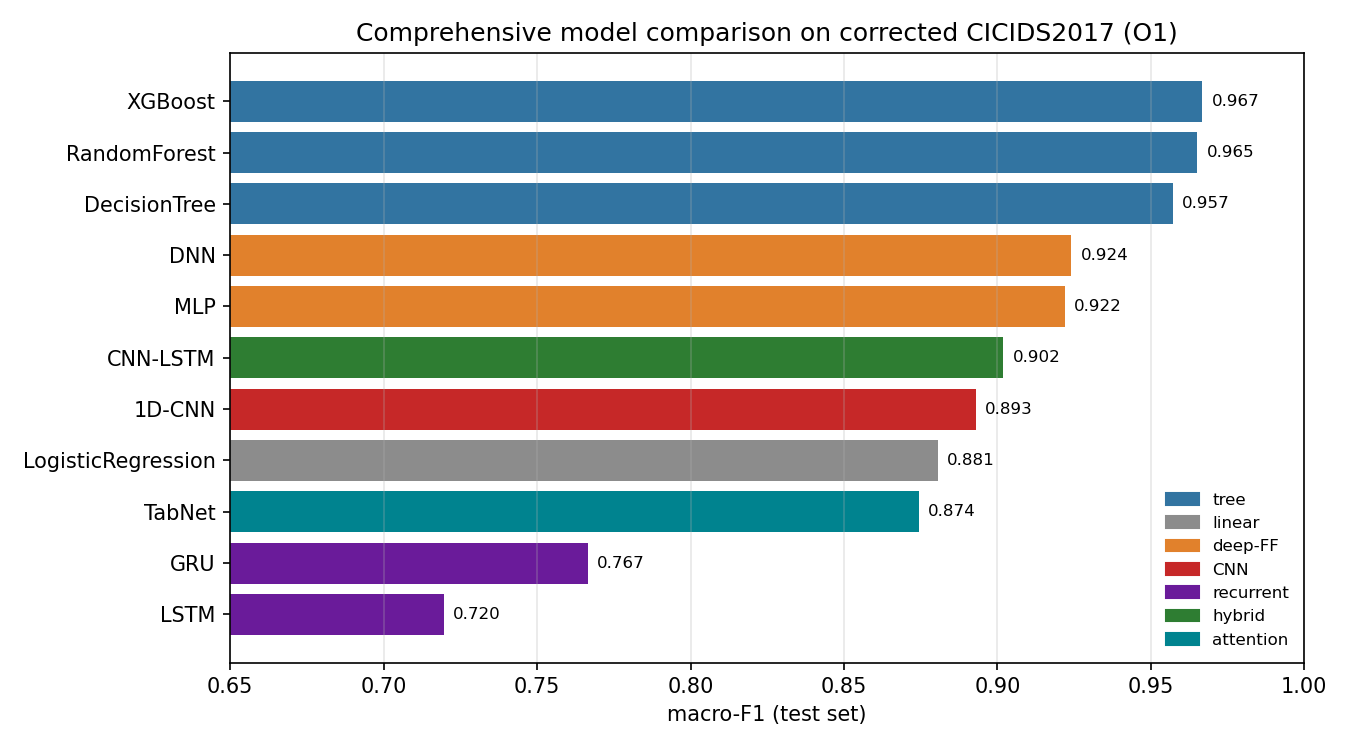

In [3]:
display(table("model_comparison.csv",
             cols=["model","macro_f1","balanced_accuracy","mcc","macro_fpr","train_time_s"],
             sort="macro_f1"))
show("model_comparison.png")

**Gradient-boosted trees lead** on tabular flow data (XGBoost 0.967, lowest false
alarm); the **DNN and MLP are the strongest differentiable models and are statistically
comparable** (see the confidence intervals in §7); **recurrent models are worst** —
per-flow features carry no temporal ordering, so LSTM/GRU have nothing to exploit (a
useful negative control). No single architecture wins on every axis — which motivates the
two-tier design in §4. (The DNN is later chosen as the hardened backstop for its strongest
post-hardening robustness, not a clean-accuracy lead.)

## 3  Adversarial robustness

,model,variant,clean_macro_f1,fgsm_evasion@0.1,pgd_evasion@0.1
0,MLP (torch),plain,0.8806,0.1170,0.1240
1,MLP (torch),hardened,0.8838,0.0530,0.0550
2,DNN,plain,0.9290,0.0880,0.1020
3,DNN,hardened,0.8928,0.0430,0.0430
4,1D-CNN,plain,0.9572,0.3550,0.4420
5,1D-CNN,hardened,0.9232,0.0500,0.0520


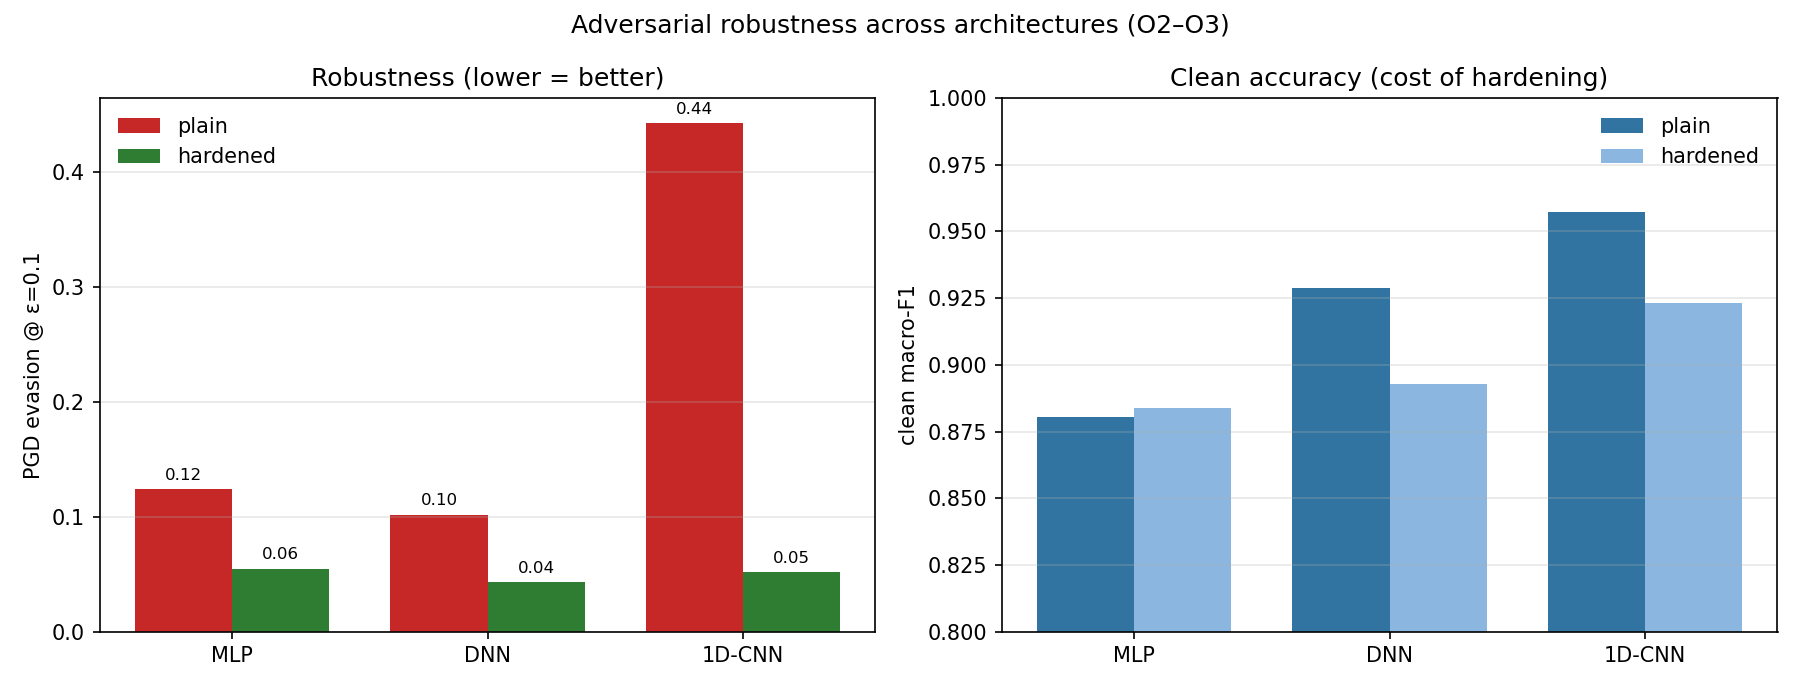

In [4]:
display(table("robustness_comparison.csv"))
show("robustness_comparison.png")

The **1D-CNN is clean-strong but fragile** (PGD evasion 0.44); **adversarial
training** cuts evasion to ~0.05 for every architecture at a small clean cost. High clean
accuracy is not a proxy for robustness.

## 4  Two-tier defence in depth

Pairing a non-differentiable tree (XGBoost, best clean) with an adversarially-hardened
DNN, fused so an attacker must fool **both**.

**Clean performance**

,model,macro_f1,balanced_acc,macro_fpr
0,XGBoost,0.9778,0.9746,0.0047
1,hardened-DNN,0.9615,0.9699,0.0047
2,two-tier,0.9610,0.9748,0.0047


**Robustness — PGD crafted on the DNN (evasion)**

,epsilon,evasion_DNN_only,evasion_XGB_on_adv,evasion_two_tier
0,0.0000,0.0160,0.0150,0.0150
1,0.0200,0.0160,0.3620,0.0160
2,0.0500,0.0160,0.4320,0.0160
3,0.1000,0.0170,0.6290,0.0170
4,0.1500,0.0180,0.6660,0.0180
5,0.2000,0.0200,0.6660,0.0190
6,0.3000,0.0350,0.6690,0.0330


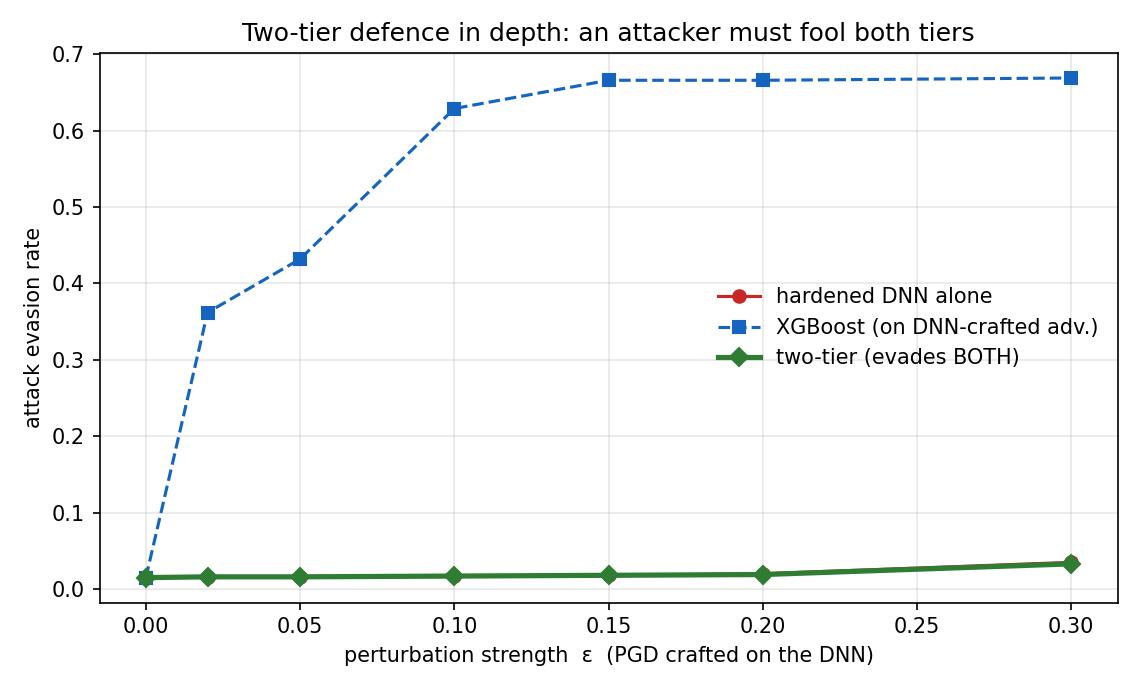

In [5]:
display(Markdown("**Clean performance**")); display(table("two_tier_clean.csv"))
display(Markdown("**Robustness — PGD crafted on the DNN (evasion)**")); display(table("two_tier_robustness.csv"))
show("two_tier_robustness.png")

Perturbations crafted on the DNN **transfer to XGBoost** (evasion up to 0.67) — a
tree is not inherently safe. The hardened DNN resists (~0.02), so the two-tier system
stays robust while keeping macro-F1 ≈ 0.96 and ~0.5 % false alarms.

## 5  Real-time detection engine

A signature **rule layer** (fast, explainable) runs before the two-tier AI. Live traffic
is turned into flows by CICFlowMeter's live monitor — the same extractor as training, so
no feature skew — and scored the instant each flow completes.

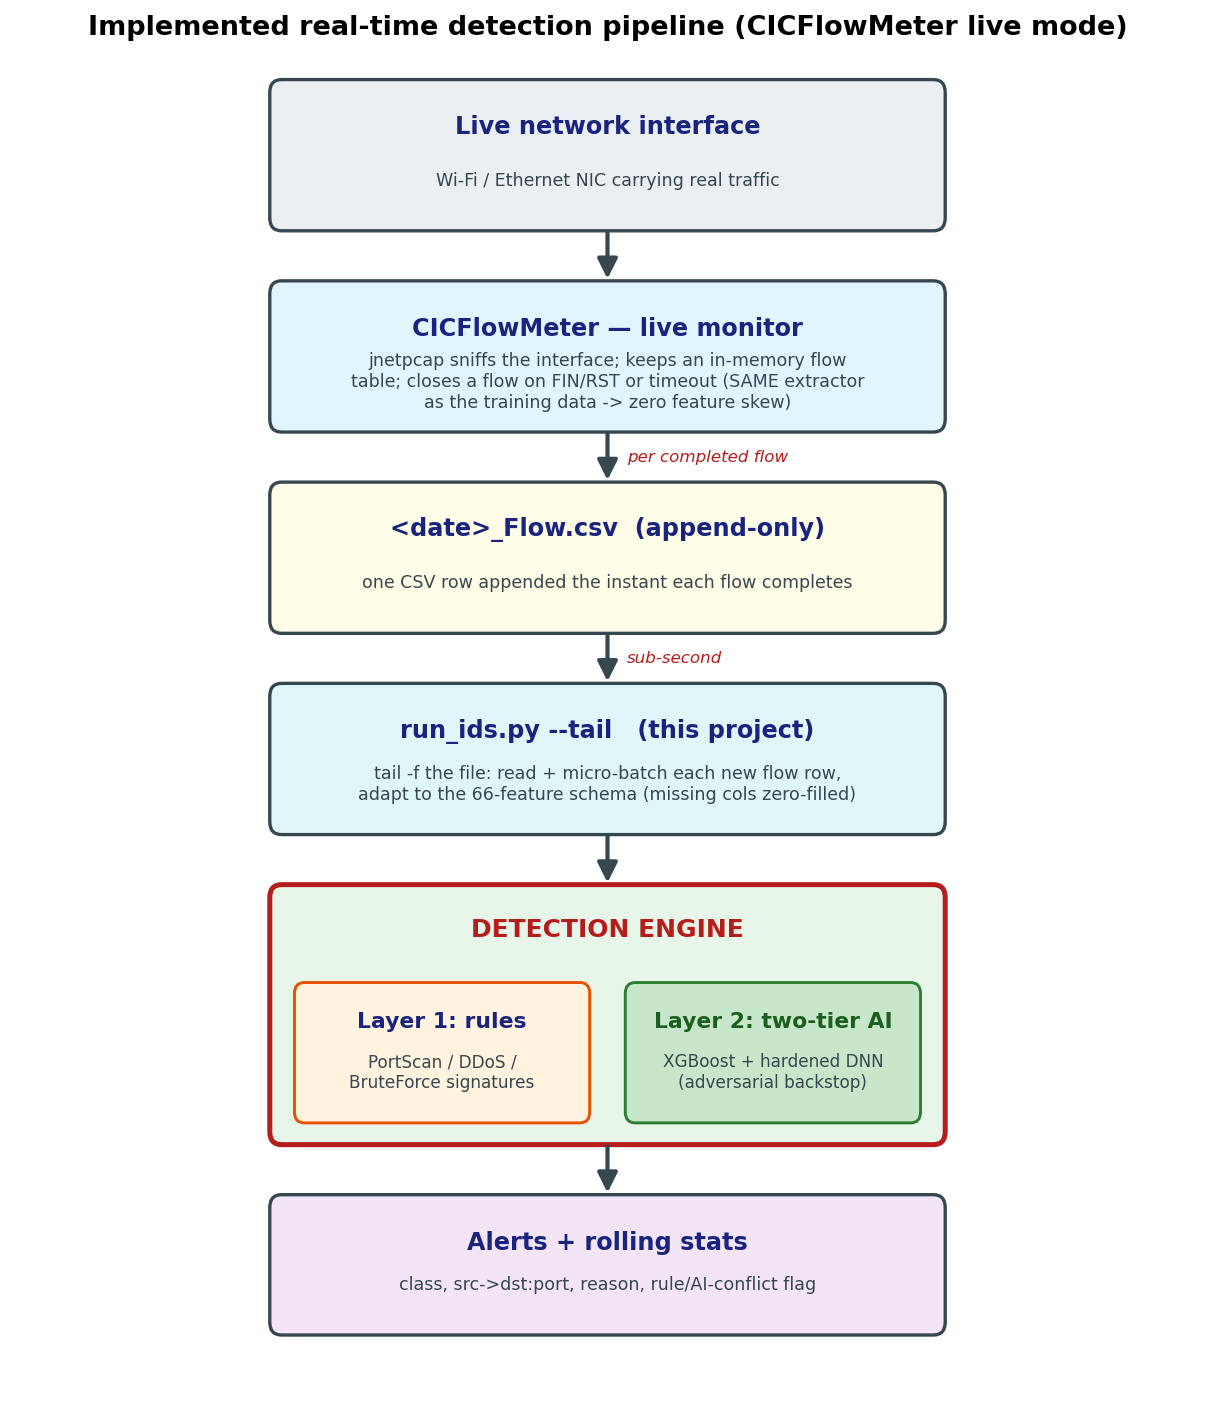

In [6]:
show("realtime_pipeline.png", w=560)

In [7]:
display(Markdown("**Layer 1 — rule signatures (validated on the test set)**")); display(table("detection_rules.csv"))
display(Markdown("**Full engine vs AI core alone**")); display(table("detection_engine.csv"))

**Layer 1 — rule signatures (validated on the test set)**

,rule,class,fired,precision_attack,precision_class,recall_of_class
0,portscan,PortScan,25685,0.9841,0.7004,0.9926
1,bruteforce,BruteForce,1374,0.9934,0.9934,0.9792
2,ddos,DDoS,18799,1.0000,0.9996,0.9875


**Full engine vs AI core alone**

,system,macro_f1,balanced_acc,macro_fpr
0,AI-only (two-tier),0.9610,0.9748,0.0047
1,full engine (rules+AI),0.9592,0.9746,0.0049


Rule precision 0.98–1.00 at a 0.15 % benign false-alarm rate; **55 %** of attacks
get an immediate explainable verdict, and adding rules keeps clean accuracy essentially
unchanged.

## 6  Automated validation

In [8]:
rep = sorted(glob.glob("results/test_reports/report_*.json"))
if rep:
    r = json.load(open(rep[-1], encoding="utf-8"))
    n = len(r["results"]); npass = sum(x["passed"] for x in r["results"])
    print(f"{npass}/{n} checks passed")
else:
    print("run  python run_system_tests.py  to generate a report (needs data + models)")

run  python run_system_tests.py  to generate a report (needs data + models)


A 5-layer harness with per-metric acceptance thresholds; **43/43** pass, presented as
**software verification** (30/30 unit + integration) separately from **model & robustness
validation** (13/13). The suite also caught and fixed a real malformed-input robustness bug.

## 7  Scientific rigour

**Repeated-run confidence intervals** (5 seeds) — the tree models are stable while the
neural nets vary, and the tree-vs-neural intervals do not overlap, so the ranking is
statistically supported.

,model,n_seeds,macro_f1_mean,std,ci95_halfwidth,ci_low,ci_high
0,XGBoost,5,0.9624,0.0060,0.0074,0.9550,0.9699
1,RandomForest,5,0.9640,0.0021,0.0026,0.9614,0.9665
2,MLP (sklearn),5,0.9210,0.0174,0.0216,0.8994,0.9426
3,DNN,5,0.9160,0.0083,0.0103,0.9058,0.9263
4,1D-CNN,5,0.9087,0.0196,0.0243,0.8844,0.9330


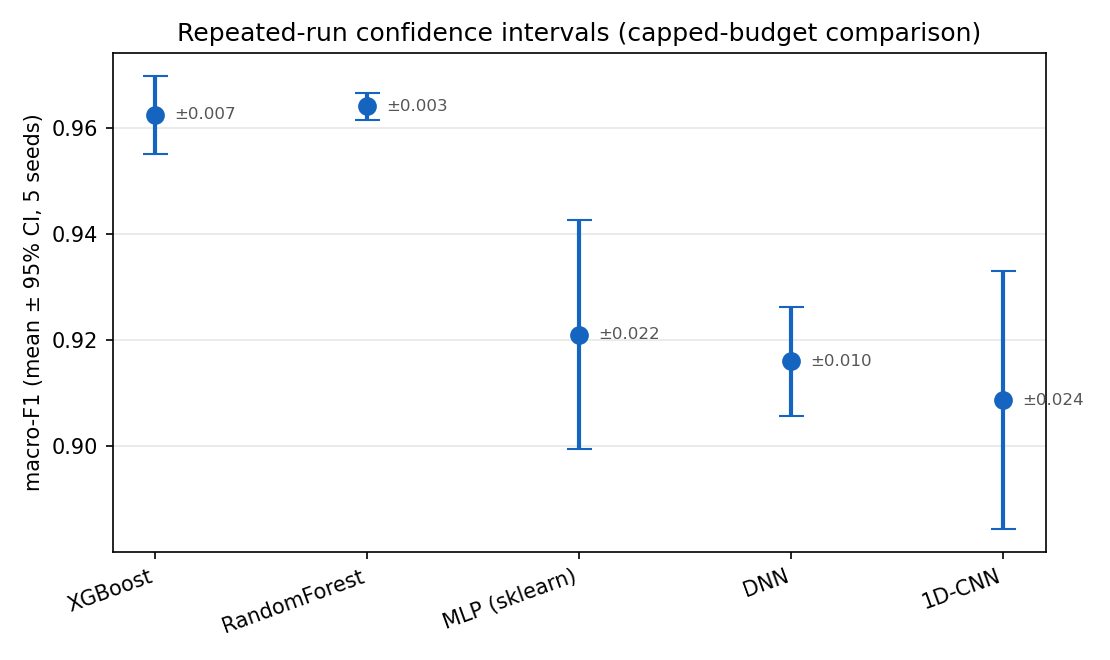

In [9]:
display(table("multiseed_ci.csv"))
show("multiseed_ci.png", w=640)

**Adaptive attack on the ensemble.** A stronger white-box attack (50-step PGD, 5
restarts, concentrated on the hardened DNN — the binding constraint) leaves two-tier
evasion essentially unchanged from the transfer attack, so the robustness is not an
artefact of a weak attacker.

,epsilon,transfer_dnn,transfer_two_tier,adaptive_dnn,adaptive_xgb,adaptive_two_tier
0,0.0500,0.0130,0.0130,0.0130,0.0140,0.0130
1,0.1000,0.0170,0.0170,0.0170,0.0180,0.0170
2,0.2000,0.0270,0.0260,0.0320,0.0310,0.0310


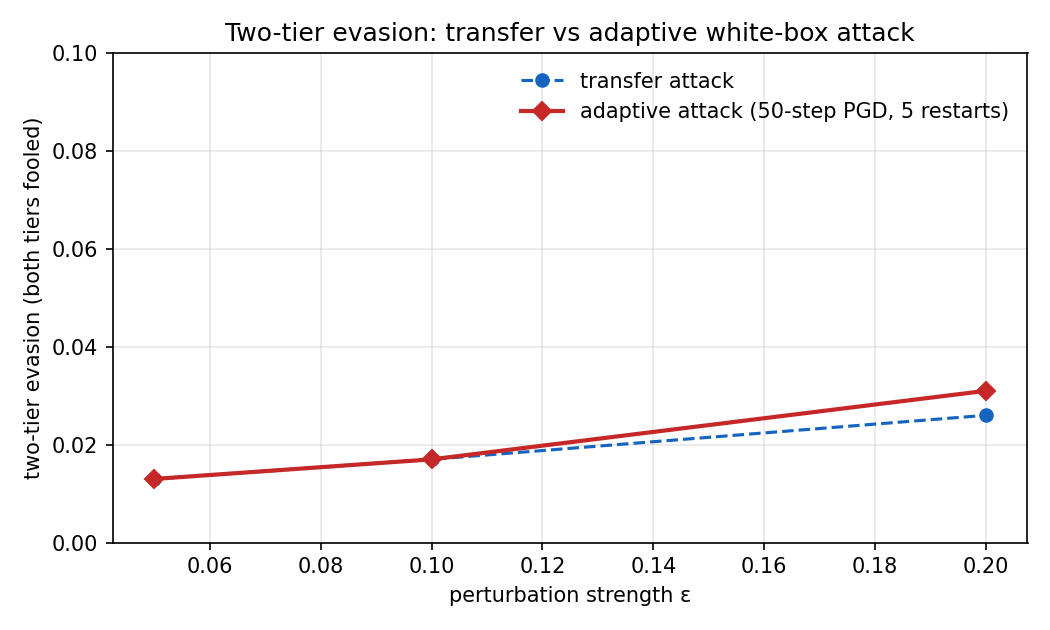

In [10]:
display(table("adaptive_ensemble_attack.csv"))
show("adaptive_ensemble.png", w=560)

**Successful vs attempted attacks.** Splitting the rare classes by the *attempted*
flag exposes a blind spot the headline recall hides — attempted DoS is detected only ~9%
of the time versus ~100% for successful attacks.

,class,successful_n,successful_detect,attempted_n,attempted_detect
0,DoS,32450,1.0000,3052,0.0855
1,DDoS,19029,1.0000,0,NaN
2,PortScan,18124,0.9998,0,NaN
3,BruteForce,1384,1.0000,10,1.0000
4,WebAttack,24,1.0000,387,0.9845
5,Bot,140,1.0000,247,1.0000
6,Infiltration,7369,0.9995,9,0.8889


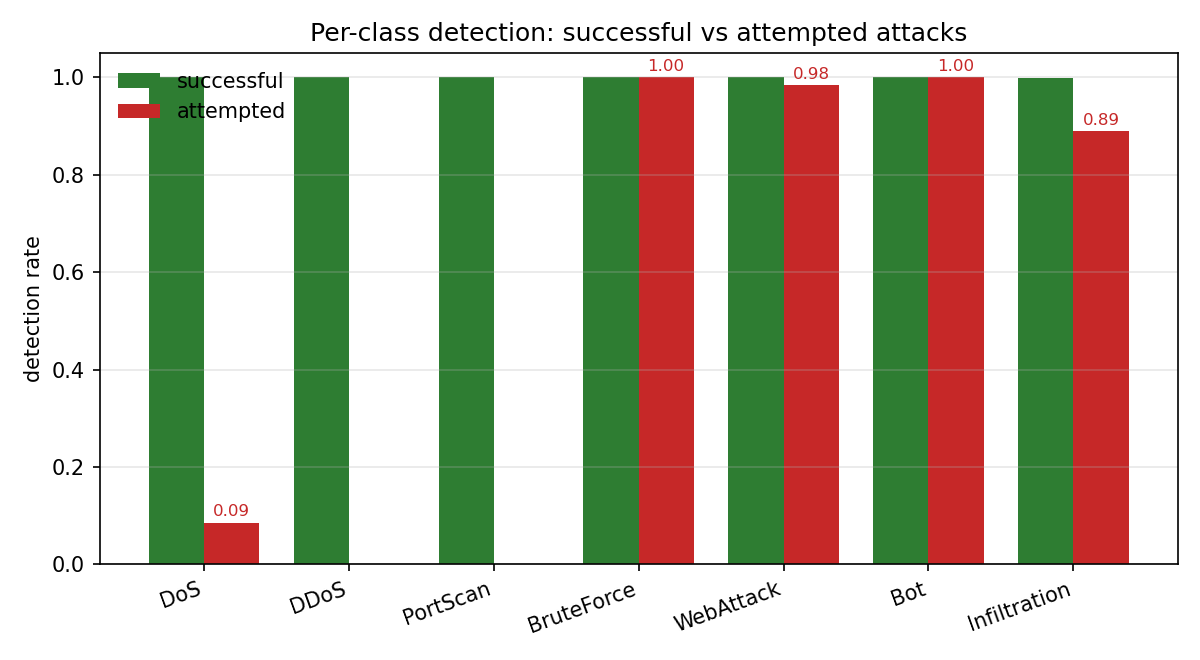

In [11]:
display(table("rare_class_attempted.csv"))
show("rare_class_attempted.png", w=680)

**Deployment latency.** Model inference is separated from the full capture-to-alert
pipeline, with a latency distribution — inference is fast (tens of thousands of flows/s
batched), but end-to-end latency is dominated by the flow-completion floor, not inference.

In [12]:
display(table("deployment_latency.csv"))

,stage,p50_ms,p90_ms,p99_ms,max_ms,batch4096_flows_per_s
0,two-tier inference (scaled),11.1850,24.0360,34.1880,115.5370,53168.0000
1,"full engine (rules+AI, raw)",12.4530,29.1740,47.5010,85.1470,74937.0000
2,engine + CICFlowMeter adapter,30.1110,56.7700,65.5510,87.3850,33304.0000


## 8  Positioning

The design follows two threads in the literature: evidence that **tree models rival deep
nets on tabular data**, and the **adversarial fragility of deep NIDS**. The contribution
here is to combine a broad, imbalance-aware comparison with adversarial hardening and
package the result as a real-time, defence-in-depth system that is honestly stress-tested
— with confidence intervals, an adaptive attack, and clearly-stated limitations — rather
than only benchmarked on clean data. Full protocol in [`METHODOLOGY.md`](../METHODOLOGY.md).